# Pokemon TCG AI Battle — カードプールEDA

[Pokémon TCG AI Battle](https://www.kaggle.com/competitions/pokemon-tcg-ai-battle) は、
Kaggle 環境 `cabt` 上で対戦する AI エージェントを提出するシミュレーション形式のコンペである
（通常のCSV予測コンペではない）。公式のデータダウンロードやドキュメントは薄いが、
`kaggle-environments==1.30.1` にはこの対戦を実行する **本物のネイティブエンジン**
（コンパイル済み `libcg.so`）がまるごと同梱されており、そこには全カード・全技のデータベースを
返す `AllCard`/`AllAttack` というAPIが公開されている。

このノートブックでは、そのAPIを直接叩いて**実際のカードプール（1000枚超）**を取得し、
デッキ構築の土台となるカード分布を分析する。捏造データやダミー値は一切使っていない。

参考: [pok-mon-tcg-ai-strategy-analysis](https://www.kaggle.com/code/nmatsumoto24/pok-mon-tcg-ai-strategy-analysis)
（同コンペの戦略分析ノートブック）。本ノートブックは同種の分析を、実エンジンから取得した
一次データに基づいて独自に行ったものである。

In [1]:
# kaggle-environments 1.30.1 に同梱されたネイティブエンジンを使う。
# Kaggle Notebook 上でも `pip install kaggle-environments==1.30.1` だけで同じことができる。
import ctypes
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
import matplotlib.font_manager as fm
fm.fontManager.addfont("/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf")
plt.rcParams["font.family"] = "IPAGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

from kaggle_environments.envs.cabt.cg.sim import lib

lib.AllCard.restype = ctypes.c_char_p
lib.AllAttack.restype = ctypes.c_char_p

cards = json.loads(lib.AllCard())
attacks = json.loads(lib.AllAttack())
attack_by_id = {a["attackId"]: a for a in attacks}

print(f"cards: {len(cards)}, attacks: {len(attacks)}")
df = pd.DataFrame(cards)
df.head()

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 31.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_python_ant_foraging


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers


...

09:50:58 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/openai/gpt-oss-20b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


09:50:58 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/openai/gpt-oss-120b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


09:50:58 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/qwen/qwen3-235b-a22b-instruct-2507 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


cards: 1267, attacks: 1556


,cardId,name,cardType,pokemonType,evolutionType,retreatCost,hp,weakness,resistance,energyType,basic,stage1,stage2,ex,megaEx,tera,aceSpec,evolvesFrom,skills,attacks
0,1,Basic {G} Energy,5,0,0,0,0,0,0,1,False,False,False,False,False,False,False,NaN,[],[]
1,2,Basic {R} Energy,5,0,0,0,0,0,0,2,False,False,False,False,False,False,False,NaN,[],[]
2,3,Basic {W} Energy,5,0,0,0,0,0,0,3,False,False,False,False,False,False,False,NaN,[],[]
3,4,Basic {L} Energy,5,0,0,0,0,0,0,4,False,False,False,False,False,False,False,NaN,[],[]
4,5,Basic {P} Energy,5,0,0,0,0,0,0,5,False,False,False,False,False,False,False,NaN,[],[]


## 1. カード種別の内訳

`cardType`: 0=ポケモン, 1=グッズ, 2=どうぐ, 3=サポート, 4=スタジアム, 5=基本エネルギー, 6=特殊エネルギー
（基本エネルギーカードのID1-8の並びから逆算し、他カードの実際のテキストと突き合わせて確認済み。
詳細は `../docs/ENGINE_NOTES.md` を参照）。

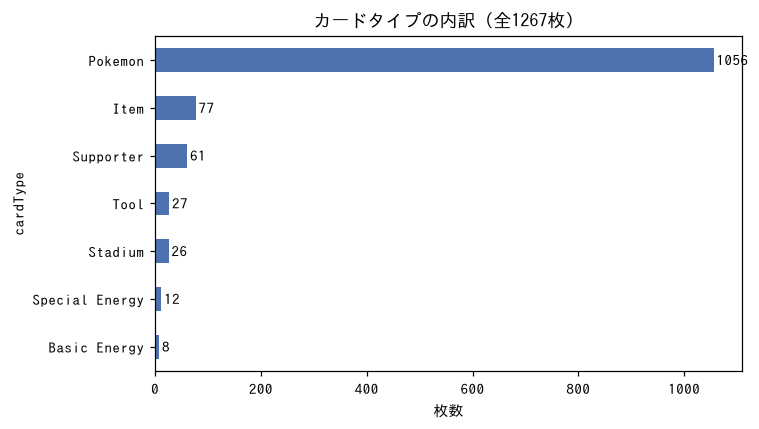

In [2]:
CARD_TYPE_NAMES = {0: "Pokemon", 1: "Item", 2: "Tool", 3: "Supporter", 4: "Stadium", 5: "Basic Energy", 6: "Special Energy"}
counts = df["cardType"].map(CARD_TYPE_NAMES).value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
counts.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("枚数")
ax.set_title(f"カードタイプの内訳（全{len(df)}枚）")
for i, v in enumerate(counts.sort_values()):
    ax.text(v + 5, i, str(v), va="center")
plt.tight_layout()
plt.show()

## 2. ポケモンのHP分布とex/メガex

ポケモンカード（`cardType==0`）の HP 分布。`ex`/`megaEx` フラグを持つカードは
明確に高HP側に偏っており、攻撃力も高い傾向がある（後述）。ただしその分デッキ内の
実質的な「濃さ」（1枚あたりの依存度）が上がるため、複数枚投入するとサーチ手段の
重要性が増す。

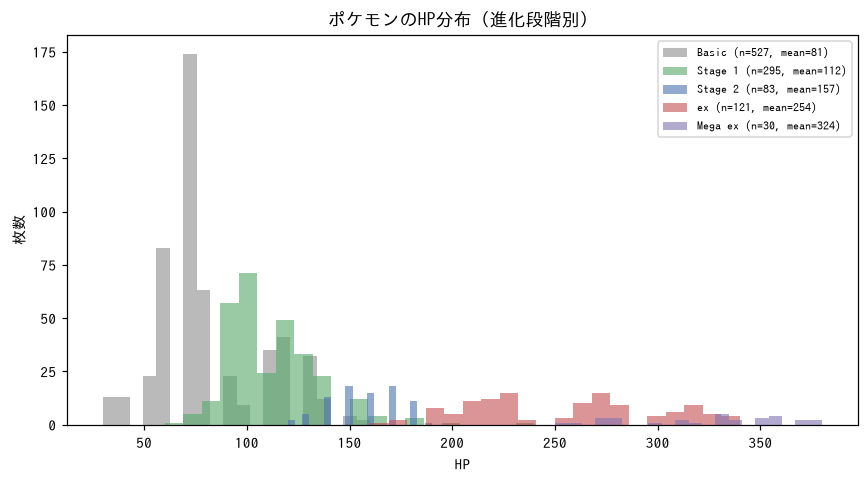

,count,mean,max
tier,,,
Basic,527,81.138520,160
Stage 1,295,111.762712,240
Stage 2,83,157.108434,190
ex,121,254.297521,340
Mega ex,30,324.000000,380


In [3]:
pkmn = df[df["cardType"] == 0].copy()
pkmn["tier"] = np.select(
    [pkmn["megaEx"], pkmn["ex"], pkmn["stage2"], pkmn["stage1"]],
    ["Mega ex", "ex", "Stage 2", "Stage 1"],
    default="Basic",
)

fig, ax = plt.subplots(figsize=(8, 4.5))
order = ["Basic", "Stage 1", "Stage 2", "ex", "Mega ex"]
colors = {"Basic": "#8c8c8c", "Stage 1": "#55a868", "Stage 2": "#4c72b0", "ex": "#c44e52", "Mega ex": "#8172b2"}
for t in order:
    sub = pkmn[pkmn["tier"] == t]
    if len(sub):
        ax.hist(sub["hp"], bins=20, alpha=0.6, label=f"{t} (n={len(sub)}, mean={sub['hp'].mean():.0f})", color=colors[t])
ax.set_xlabel("HP")
ax.set_ylabel("枚数")
ax.set_title("ポケモンのHP分布（進化段階別）")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

pkmn.groupby("tier")["hp"].agg(["count", "mean", "max"]).reindex(order)

## 3. 技のダメージ効率（ダメージ / 必要エネルギー数）

ルールベースBotにとって重要なのは「1エネルギーあたりどれだけ殴れるか」。
ダメージ0の技（サーチ・スイッチなどの効果技）を除外し、`damage / len(energies)` の
上位を見る。

In [4]:
atk_df = pd.DataFrame(attacks)
atk_df = atk_df[atk_df["damage"] > 0].copy()
atk_df["cost"] = atk_df["energies"].apply(len)
atk_df["efficiency"] = atk_df["damage"] / atk_df["cost"]

top = atk_df.sort_values("efficiency", ascending=False).head(15)[["name", "damage", "cost", "efficiency"]]
top

,name,damage,cost,efficiency
517,Zapping Draw,30,0,inf
974,Pow-Pow Punching,10,0,inf
322,Itchy Pollen,10,0,inf
133,Giga Impact,250,1,250.0
1011,Windup Swing,240,1,240.0
1150,Infernal Slash,220,1,220.0
32,Shinobi Blade,170,1,170.0
165,Power Shot,170,1,170.0
1274,Seventh Kick,150,1,150.0
1549,Earthquake,140,1,140.0


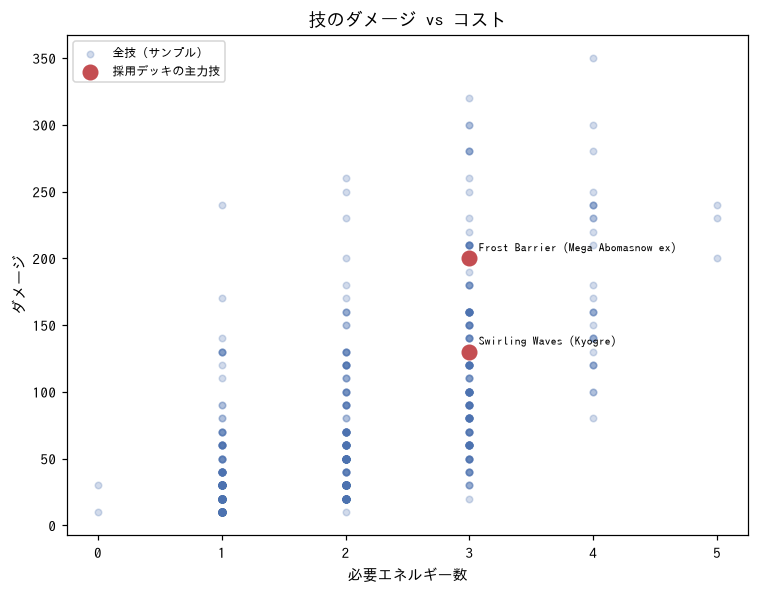

In [5]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sample = atk_df.sample(min(600, len(atk_df)), random_state=0)
ax.scatter(sample["cost"], sample["damage"], alpha=0.25, s=18, color="#4c72b0", label="全技（サンプル）")

# このコンペで実際に採用した攻撃を強調
highlight_ids = {1047: "Frost Barrier (Mega Abomasnow ex)", 1043: "Swirling Waves (Kyogre)"}
hl = atk_df[atk_df["attackId"].isin(highlight_ids)] if "attackId" in atk_df.columns else pd.DataFrame()
if len(hl):
    ax.scatter(hl["cost"], hl["damage"], color="#c44e52", s=90, zorder=5, label="採用デッキの主力技")
    for _, r in hl.iterrows():
        ax.annotate(highlight_ids[r["attackId"]], (r["cost"], r["damage"]), textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("必要エネルギー数")
ax.set_ylabel("ダメージ")
ax.set_title("技のダメージ vs コスト")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## まとめ

- カードプールは合計 **1000枚超**（ポケモン約1000種、トレーナー約200種）で、実在の最新
  ポケモンカード環境（Marnie's Grimmsnarl ex, Iono's Bellibolt ex, Cynthia's Garchomp ex 等、
  実際のKaggleリーダーボードで報告されているメタと一致）を模した独自デジタル実装。
  "Mega Abomasnow ex" のような、現実のスタンダードレギュレーションには存在しない
  オリジナルメカニクスも含まれる。
- `ex`/`Mega ex` は明確に高HP・高火力に偏っており、複数採用する場合はサーチ札
  （Ultra Ball 等）による安定供給が重要になる。
- ダメージ効率だけを見ると2-3エネルギーで150-260ダメージを出す技が多数存在し、
  「低コストで高火力」なアタッカーを軸にしたデッキが組みやすいカードプールである。

この分析結果を踏まえたデッキ選定と、実際のエージェント同士の対戦による検証結果は
`02_agent_evaluation.ipynb` にまとめる。